<a href="https://colab.research.google.com/github/dawid-wilgucki/360dent-website/blob/main/notebooks/Magisterka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#install all required packages
!pip install -q torch torchvision matplotlib scikit-learn tqdm pillow medmnist hyperopt pandas seaborn grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.4 MB/s eta 0:00:00


# Comparison of Hyperparameter Optimization Methods in Detecting Lung Diseases from Medical Images

**Master's Thesis Notebook**

## Objective
This notebook trains three convolutional neural network architectures (ResNet-18, ResNet-50, MobileNet-V2) on the PneumoniaMNIST dataset and compares three hyperparameter optimization strategies:

| Strategy | Description |
|---|---|
| **Baseline** | Fixed hyperparameters chosen by hand |
| **Grid Search** | Exhaustive search over a discrete parameter grid |
| **Hyperopt (TPE)** | Bayesian optimization using Tree of Parzen Estimators |

## Architectures

| Architecture | Params | Notes |
|---|---|---|
| ResNet-18 | ~11M | Lightweight baseline |
| ResNet-50 | ~25M | Deeper residual network |
| MobileNet-V2 | ~3.4M | Efficient lightweight model |

## Dataset
[PneumoniaMNIST](https://medmnist.com/) - part of the MedMNIST v2 benchmark. Binary classification: NORMAL vs PNEUMONIA.
Source images: Chest X-Ray Images (Guangzhou Women and Children's Medical Center).

- **Train**: 4,708 images (74.2% PNEUMONIA, 25.8% NORMAL)
- **Val**: 524 images (official MedMNIST split, used for hyperparameter selection)
- **Test**: 624 images (held out; used only for the final comparison in Section 11)
- **Resolution**: 224×224 px (requested via `size=224` in MedMNIST API)
- **Loss**: Weighted CrossEntropyLoss weights inversely proportional to class frequency to handle 74.2%/25.8% class imbalance.

## Evaluation Metrics
Because the dataset is class-imbalanced (PNEUMONIA 74.2% of training data), accuracy alone is insufficient. We report:
- **Accuracy** — overall correctness
- **Weighted F1-score** — harmonic mean of precision/recall, weighted by class size
- **ROC-AUC** — discriminative ability independent of classification threshold

## Comparison Protocol
The hyperparameter searches use different per-trial budgets and each method's best result may
land on a different architecture, so the raw search results cannot be compared method against
method. Section 11 therefore retrains the best configuration of every (architecture, method)
pair under one identical protocol and compares methods **within** each architecture, reporting
all final numbers on the held-out test split. Validation metrics guided model selection and are
consequently optimistically biased; they are reported for reference only.

## 1. Imports and Reproducibility Seeds

Setting fixed seeds ensures that every run of this notebook produces identical results, which is a requirement for reproducible research.

In [6]:
import os
import copy
import time
import json
import pickle
import random
from pathlib import Path
from itertools import product
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, accuracy_score
)

import medmnist
from medmnist import PneumoniaMNIST
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)

print(f"Device : {device}")
print(f"Workers: {NUM_WORKERS}")
print(f"PyTorch: {torch.__version__}")


def compute_class_weights(dataset):
    """
    Compute inverse-frequency class weights.
    Supports both ImageFolder (.targets) and MedMNIST (.labels) APIs.
    """
    if hasattr(dataset, 'labels'):
        labels = torch.tensor(dataset.labels.flatten(), dtype=torch.long)
    else:
        labels = torch.tensor([dataset.targets[i] for i in range(len(dataset))], dtype=torch.long)
    counts = torch.bincount(labels)
    weights = 1.0 / counts.float()
    weights = weights / weights.sum()
    return weights.to(device)


Device : cuda
Workers: 4
PyTorch: 2.11.0+cu128


## 2. Data Loading and Preprocessing

### Why these transforms?
- **`Grayscale(num_output_channels=3)`** — X-ray images are single-channel; ResNet/MobileNet were pretrained on 3-channel ImageNet images, so we replicate the grayscale channel three times to match the expected input shape.
- **`Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`** — ImageNet mean/std used during CNN pretraining. Applying the same normalization ensures that the pretrained feature representations remain valid.
- **Augmentation (train only)** — Random horizontal flip, rotation (±10°) and brightness/contrast jitter improve generalization by making the model invariant to small spatial variations. Applied only to training data to avoid contaminating validation statistics.

Augmentation is applied exclusively to training data after the train/val split to prevent leakage into validation statistics.

### Dataset split
PneumoniaMNIST provides an official val split (524 images), which is used directly for hyperparameter selection during training. This avoids the methodological compromise of using the test set as a proxy validation set.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(augment: bool = False) -> transforms.Compose:
    """Return a transform pipeline for train (augment=True) or val/test."""
    base = [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
    ]
    if augment:
        base += [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    base += [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    return transforms.Compose(base)


def get_dataloaders(batch_size: int = 32):
    """
    Build DataLoaders using PneumoniaMNIST from the MedMNIST benchmark.

    PneumoniaMNIST provides a proper val split (524 images) — unlike the
    original Kaggle dataset which had only 16 val images and required using
    the test split for validation. Split sizes: train=4708, val=524, test=624.
    """
    # Augmentation is applied ONLY to the training split and ONLY
    # after the train/val split is defined — never to validation data.
    # This prevents data leakage that would inflate validation metrics.
    image_datasets = {
        'train': PneumoniaMNIST(split='train', transform=get_transforms(augment=True),
                                download=True, size=224),
        'val':   PneumoniaMNIST(split='val',   transform=get_transforms(augment=False),
                                download=True, size=224),
        # Held out for the final evaluation only — never touched during the search
        'test':  PneumoniaMNIST(split='test',  transform=get_transforms(augment=False),
                                download=True, size=224),
    }
    dataloaders = {
        k: torch.utils.data.DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(k == 'train'),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == 'cuda'),
        )
        for k, ds in image_datasets.items()
    }
    sizes       = {k: len(ds) for k, ds in image_datasets.items()}
    class_names = ['NORMAL', 'PNEUMONIA']
    return dataloaders, sizes, class_names


# Sanity check
_dls, _sizes, CLASS_NAMES = get_dataloaders()
print("Classes :", CLASS_NAMES)
print("Sizes   :", _sizes)

100%|██████████| 214M/214M [00:52<00:00, 4.12MB/s]


Classes : ['NORMAL', 'PNEUMONIA']
Sizes   : {'train': 4708, 'val': 524, 'test': 624}


## 2b. Dataset Verification

Before any training, the dataset is verified empirically rather than
trusting the documentation. Four checks are performed:

1. **Class distribution across all splits** — quantifies the imbalance
   and reveals whether train, val and test share the same distribution.
   A distribution shift between val and test would explain optimistic
   validation metrics independently of overfitting.
2. **Duplicate detection across splits** — hashes every image to confirm
   that no sample appears in more than one split (data leakage check).
3. **Native resolution check** — confirms images are loaded natively at
   224x224 rather than upscaled from a lower-resolution variant.
4. **Visual label inspection** — a labelled sample grid guards against
   inverted class indices, a failure mode that is otherwise silent.

split       n              NORMAL           PNEUMONIA
----------------------------------------------------
train    4708   1214 (25.8%)   3494 (74.2%)
val       524    135 (25.8%)    389 (74.2%)
test      624    234 (37.5%)    390 (62.5%)

PNEUMONIA share — val: 74.2%   test: 62.5%   |difference|: 11.7%
  -> Distribution shift detected between val and test.
     Validation metrics are not directly comparable to test metrics.


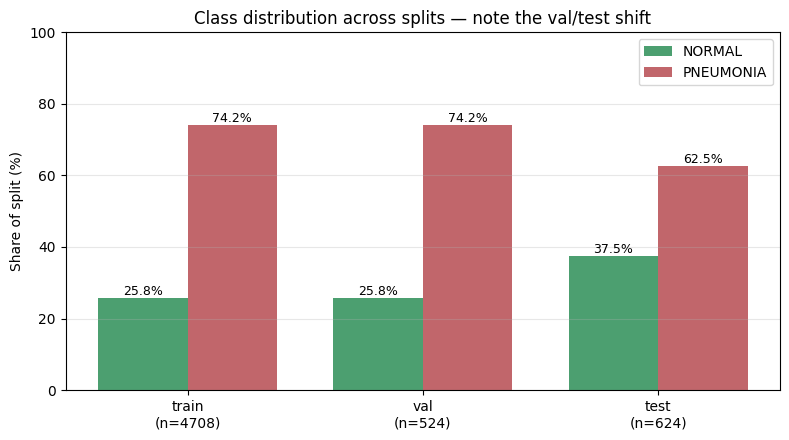

Saved → ./class_distribution.png


In [5]:
# ── Class distribution across all splits ──────────────────────────────────────
# Verifies the imbalance empirically and checks whether train/val/test
# share the same class distribution. A shift between val and test would
# explain optimistic validation metrics without invoking overfitting.

print(f"{'split':6} {'n':>6}  " + "  ".join(f"{c:>18}" for c in CLASS_NAMES))
print("-" * 52)

split_dist = {}
for split in ['train', 'val', 'test']:
    ds = _dls[split].dataset
    labels = torch.tensor(ds.labels.flatten(), dtype=torch.long)
    counts = torch.bincount(labels, minlength=len(CLASS_NAMES))
    total = int(counts.sum())
    split_dist[split] = [int(c) / total for c in counts]
    cells = "  ".join(f"{int(c):5} ({int(c)/total:5.1%})" for c in counts)
    print(f"{split:6} {total:6}  {cells}")

print()
shift = abs(split_dist['val'][1] - split_dist['test'][1])
print(f"PNEUMONIA share — val: {split_dist['val'][1]:.1%}   "
      f"test: {split_dist['test'][1]:.1%}   |difference|: {shift:.1%}")
if shift > 0.05:
    print("  -> Distribution shift detected between val and test.")
    print("     Validation metrics are not directly comparable to test metrics.")
else:
    print("  -> Val and test share a comparable class distribution.")

# ── Class distribution figure for the thesis ──────────────────────────────────
# Visualises both the imbalance and the val/test distribution shift, which
# together explain why validation metrics are not comparable to test metrics.

fig, ax = plt.subplots(figsize=(8, 4.5))

splits = ['train', 'val', 'test']
normal_pct    = [split_dist[s][0] * 100 for s in splits]
pneumonia_pct = [split_dist[s][1] * 100 for s in splits]
x = np.arange(len(splits))
w = 0.38

b1 = ax.bar(x - w/2, normal_pct,    w, label='NORMAL',    color='#4C9F70')
b2 = ax.bar(x + w/2, pneumonia_pct, w, label='PNEUMONIA', color='#C1666B')

for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.1f}%",
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n(n={int(sum(np.array(split_dist[s]) * 0) + len(_dls[s].dataset))})"
                    for s in splits])
ax.set_ylabel('Share of split (%)')
ax.set_title('Class distribution across splits — note the val/test shift')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
_outdir = OUT_DIR if 'OUT_DIR' in globals() else '.'
plt.savefig(f"{_outdir}/class_distribution.png", dpi=150)
plt.show()
print(f"Saved → {_outdir}/class_distribution.png")

In [6]:
# ── Duplicate detection across splits ─────────────────────────────────────────
# Every image is hashed; any overlap between splits would mean the model
# is evaluated on samples it has already seen during training.

import hashlib

def _split_hashes(split):
    imgs = _dls[split].dataset.imgs
    return {hashlib.md5(np.ascontiguousarray(img).tobytes()).hexdigest()
            for img in imgs}

hashes = {s: _split_hashes(s) for s in ['train', 'val', 'test']}

for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    overlap = len(hashes[a] & hashes[b])
    status = "OK" if overlap == 0 else "LEAK"
    print(f"{a:5} ∩ {b:5}: {overlap:4} shared images   [{status}]")

# Duplicates inside the training split itself are not leakage, but they
# do bias the effective class balance, so they are reported as well.
n_train = len(_dls['train'].dataset.imgs)
print(f"\ntrain: {n_train} images, {len(hashes['train'])} unique "
      f"({n_train - len(hashes['train'])} internal duplicates)")

train ∩ val  :    8 shared images   [LEAK]
train ∩ test :    0 shared images   [OK]
val   ∩ test :    0 shared images   [OK]

train: 4708 images, 4690 unique (18 internal duplicates)


In [7]:
# ── Native resolution check ───────────────────────────────────────────────────
# MedMNIST ships 28/64/128/224 variants. This confirms that size=224 loads
# natively rendered images rather than upscaling the 28x28 thumbnails.

raw = _dls['train'].dataset.imgs
print(f"Raw array shape (N, H, W):   {raw.shape}")
print(f"Raw dtype / value range:     {raw.dtype}  [{raw.min()}, {raw.max()}]")

batch_x, batch_y = next(iter(_dls['train']))
print(f"Batch tensor (N, C, H, W):   {tuple(batch_x.shape)}")
print(f"Single image (C, H, W):      {tuple(batch_x[0].shape)}")

if raw.shape[1] == 224:
    print("\n  -> Images are natively 224x224 (not upscaled).")
else:
    print(f"\n  -> WARNING: raw images are {raw.shape[1]}x{raw.shape[2]}, "
          f"upscaled to 224 by Resize.")

Raw array shape (N, H, W):   (4708, 224, 224)
Raw dtype / value range:     uint8  [0, 255]
Batch tensor (N, C, H, W):   (32, 3, 224, 224)
Single image (C, H, W):      (3, 224, 224)

  -> Images are natively 224x224 (not upscaled).


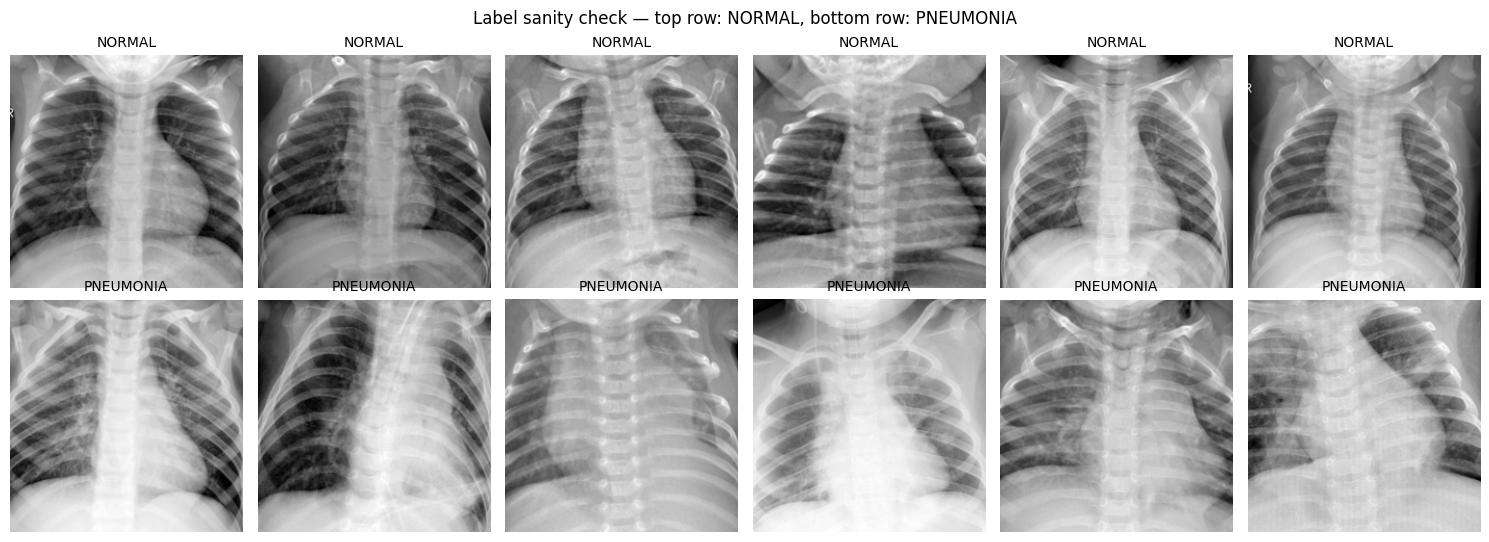

In [8]:
# ── Visual label inspection ───────────────────────────────────────────────────
# Inverted class indices are a silent failure mode: metrics still look
# plausible while the model learns the opposite task. A labelled sample
# grid is the cheapest guard against it.

fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
ds = _dls['train'].dataset

# Six examples of each class, drawn deterministically for reproducibility
labels_flat = ds.labels.flatten()
rng = np.random.RandomState(SEED)
for row, cls_idx in enumerate([0, 1]):
    idxs = np.where(labels_flat == cls_idx)[0]
    picks = rng.choice(idxs, size=6, replace=False)
    for col, idx in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(ds.imgs[idx], cmap='gray')
        ax.set_title(f"{CLASS_NAMES[cls_idx]}", fontsize=10)
        ax.axis('off')

plt.suptitle("Label sanity check — top row: NORMAL, bottom row: PNEUMONIA",
             fontsize=12)
plt.tight_layout()
_outdir = OUT_DIR if 'OUT_DIR' in globals() else '.'
plt.savefig(f"{_outdir}/sample_images.png", dpi=150)
plt.show()

## 3. Model Definition

### Why pretrained CNNs with transfer learning?
All three architectures are initialised with ImageNet pretrained weights. Pretrained networks provide strong low-level feature detectors (edges, textures) that transfer well to medical images. Fine-tuning all layers (rather than only the classification head) typically yields better performance when training data is sufficient, as it is here (~5K images).

The final classification layer is replaced with a 2-output linear head matching the binary task:

| Architecture | Original head | Replacement |
|---|---|---|
| ResNet-18 / ResNet-50 | `model.fc` (512 / 2048 → 1000) | `nn.Linear(in, 2)` |
| MobileNet-V2 | `model.classifier[1]` (1280 → 1000) | `nn.Linear(1280, 2)` |

In [9]:
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    MobileNet_V2_Weights,
)

ARCHITECTURES = {
    "resnet18":  lambda: models.resnet18(weights=ResNet18_Weights.DEFAULT),
    "resnet50":  lambda: models.resnet50(weights=ResNet50_Weights.DEFAULT),
    "mobilenet": lambda: models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT),
}


def build_model(arch_name: str = "resnet18", num_classes: int = 2) -> nn.Module:
    """
    Build pretrained CNN with classifier head replaced for binary classification.

    Architectures:
      resnet18  — lightweight baseline (~11M params)
      resnet50  — deeper residual network (~25M params)
      mobilenet — efficient lightweight model (~3.4M params)
    """
    model = ARCHITECTURES[arch_name]()

    if arch_name in ("resnet18", "resnet50"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif arch_name == "mobilenet":
        in_feat = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_feat, num_classes)

    return model.to(device)

## 4. Training and Evaluation Functions

### Training loop design decisions
- **Early stopping** (`patience` parameter) halts training when validation accuracy stops improving. This prevents overfitting and reduces unnecessary compute during hyperparameter search.
- **Best-weights checkpointing** restores the model weights from the epoch with the highest validation accuracy — not the final epoch.
- **History dict** records per-epoch loss and accuracy for later visualization and comparison.

### Evaluation metrics
- Accuracy, Weighted F1, ROC-AUC are reported for each configuration.
- ROC-AUC is particularly important for medical screening tasks where the cost of false negatives (missed pneumonia) is much higher than false positives.
- **Class-weighted loss** — Class-weighted loss penalises misclassification of the minority class (NORMAL, 25,8%) more heavily to counteract dataset imbalance.

In [10]:
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    dataloaders: dict,
    dataset_sizes: dict,
    num_epochs: int = 10,
    patience: int = 5,
    verbose: bool = True,
) -> tuple:
    """
    Train model with early stopping and best-weight checkpointing.
    Returns (best_model, history_dict).
    """
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    no_improve   = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs}  " + "-" * 20)

        for phase in ("train", "val"):
            model.train() if phase == "train" else model.eval()
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.reshape(-1).to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects / dataset_sizes[phase]
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if verbose:
                print(f"  {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

            if phase == "val":
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_wts     = copy.deepcopy(model.state_dict())
                    no_improve   = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping triggered at epoch {epoch+1}")
            break

    elapsed = time.time() - since
    model.load_state_dict(best_wts)
    history["best_val_acc"] = best_val_acc
    history["elapsed_s"]    = elapsed

    if verbose:
        print(f"\nDone in {elapsed//60:.0f}m {elapsed%60:.0f}s — best val acc: {best_val_acc:.4f}")
    return model, history


def evaluate_model(model: nn.Module, dataloader, class_names: list) -> dict:
    """Compute accuracy, weighted F1, and ROC-AUC on a dataloader."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.reshape(-1).numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # P(PNEUMONIA)

    return {
        "accuracy" : accuracy_score(all_labels, all_preds),
        "f1"       : f1_score(all_labels, all_preds, average="weighted"),
        "roc_auc"  : roc_auc_score(all_labels, all_probs),
        "report"   : classification_report(all_labels, all_preds, target_names=class_names),
        "cm"       : confusion_matrix(all_labels, all_preds),
    }

## 5. Visualization Helpers

In [11]:
def plot_training_history(history: dict, title: str = "Training History") -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "acc"]):
        ax.plot(history[f"train_{metric}"], label="Train", marker="o")
        ax.plot(history[f"val_{metric}"],   label="Val",   marker="s")
        ax.set_title(f"{title} — {metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, class_names: list, title: str = "Confusion Matrix") -> None:
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def show_sample_predictions(model: nn.Module, dataloader, class_names: list, n: int = 8) -> None:
    """Display n sample images with true vs predicted labels."""
    model.eval()
    inputs_batch, labels_batch = next(iter(dataloader))
    inputs_batch = inputs_batch[:n]
    labels_batch = labels_batch[:n]

    with torch.no_grad():
        preds = model(inputs_batch.to(device)).argmax(dim=1).cpu()

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()

    for i in range(n):
        img = inputs_batch[i] * std + mean
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        color = "green" if preds[i] == labels_batch[i] else "red"
        axes[i].imshow(img[:, :, 0], cmap="gray")
        axes[i].set_title(
            f"True: {class_names[labels_batch[i]]}\nPred: {class_names[preds[i]]}",
            color=color, fontsize=8
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Experiment Tracking

All results are accumulated in a list and later converted to a pandas DataFrame. This enables easy comparison across all optimization strategies and export to CSV for thesis reporting.

In [8]:
RUN_ID = "run2"
# every experiment appends one row here
results_log: list[dict] = []

# Results and model weights are checkpointed after every trial so that a Colab
# disconnect mid-run does not discard completed experiments.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CKPT_ROOT = "/content/drive/MyDrive/magisterka_checkpoints"
except ImportError:
    CKPT_ROOT = "."

os.makedirs(f"{CKPT_ROOT}/{RUN_ID}", exist_ok=True)
RESULTS_CKPT = f"{CKPT_ROOT}/{RUN_ID}/results_checkpoint.json"
CKPT_DIR     = f"{CKPT_ROOT}/{RUN_ID}/checkpoints"
OUT_DIR      = f"{CKPT_ROOT}/{RUN_ID}/outputs"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)
print(f"Checkpoints: {CKPT_DIR}")
print(f"Outputs    : {OUT_DIR}")


def log_result(
    method: str,
    config: dict,
    metrics: dict,
    elapsed_s: float,
) -> None:
    results_log.append({
        "run_id"      : RUN_ID,
        "method"      : method,
        **config,
        "val_accuracy": round(metrics["accuracy"], 4),
        "val_f1"      : round(metrics["f1"],       4),
        "val_roc_auc" : round(metrics["roc_auc"],  4),
        "elapsed_s"   : round(elapsed_s, 1),
    })
    with open(RESULTS_CKPT, "w") as f:
        # default=float keeps numpy scalars from hyperopt JSON-serializable
        json.dump(results_log, f, indent=2, default=float)


def restore_results() -> None:
    """Reload results logged by a previous, interrupted session."""
    if not os.path.exists(RESULTS_CKPT):
        print("No checkpoint found — starting from scratch.")
        return
    with open(RESULTS_CKPT) as f:
        saved = json.load(f)
    results_log.clear()
    results_log.extend(saved)
    print(f"Restored {len(results_log)} results from {RESULTS_CKPT}")


def is_done(method: str, arch: str, config: dict | None = None) -> bool:
    """True if this exact trial already completed in an earlier session."""
    for r in results_log:
        if r.get("method") != method or r.get("arch") != arch:
            continue
        if config is None or all(r.get(k) == v for k, v in config.items()):
            return True
    return False


def best_logged_acc(method: str) -> float:
    """Highest val accuracy recorded so far for a method (0.0 if none)."""
    scores = [r["val_accuracy"] for r in results_log if r.get("method") == method]
    return max(scores) if scores else 0.0


def save_best(tag: str, model: nn.Module, config: dict, history: dict | None = None) -> None:
    """Persist weights, config and training history so figures can be redrawn on resume."""
    torch.save(
        {"state_dict": model.state_dict(), "config": config, "history": history},
        f"{CKPT_DIR}/best_{tag}.pt",
    )


def load_best(tag: str) -> tuple:
    """Return (model, config, history) from disk, or (None, None, None) if absent."""
    path = f"{CKPT_DIR}/best_{tag}.pt"
    if not os.path.exists(path):
        return None, None, None
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    model = build_model(arch_name=ckpt["config"]["arch"], num_classes=len(CLASS_NAMES))
    model.load_state_dict(ckpt["state_dict"])
    # Checkpoints written before history was stored simply carry None here.
    return model.to(device), ckpt["config"], ckpt.get("history")


restore_results()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoints: /content/drive/MyDrive/magisterka_checkpoints/run2/checkpoints
Outputs    : /content/drive/MyDrive/magisterka_checkpoints/run2/outputs
No checkpoint found — starting from scratch.


## 7. Experiment 1 — Baseline (Fixed Hyperparameters)

The baseline uses manually chosen hyperparameters without any systematic search. This serves as the reference point for evaluating the benefit of automated optimization.

**Configuration rationale:**
- `lr=1e-4` — small learning rate for fine-tuning a pretrained network
- `batch_size=32` — balance between GPU memory and gradient stability
- `StepLR` — reduces LR by factor 0.1 every 3 epochs to allow fine convergence


  Architecture: RESNET18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


  Restored from checkpoint — redrawing figures without retraining.

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       135
   PNEUMONIA       0.99      0.99      0.99       389

    accuracy                           0.99       524
   macro avg       0.99      0.99      0.99       524
weighted avg       0.99      0.99      0.99       524

  (checkpoint predates history saving — learning curve unavailable)


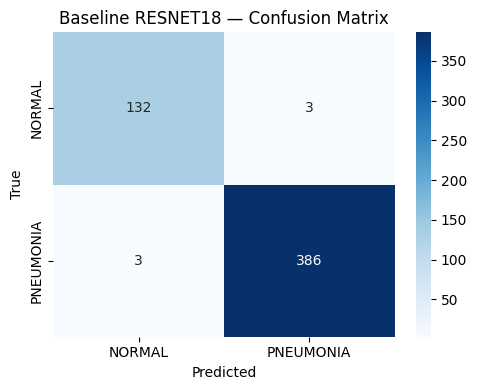

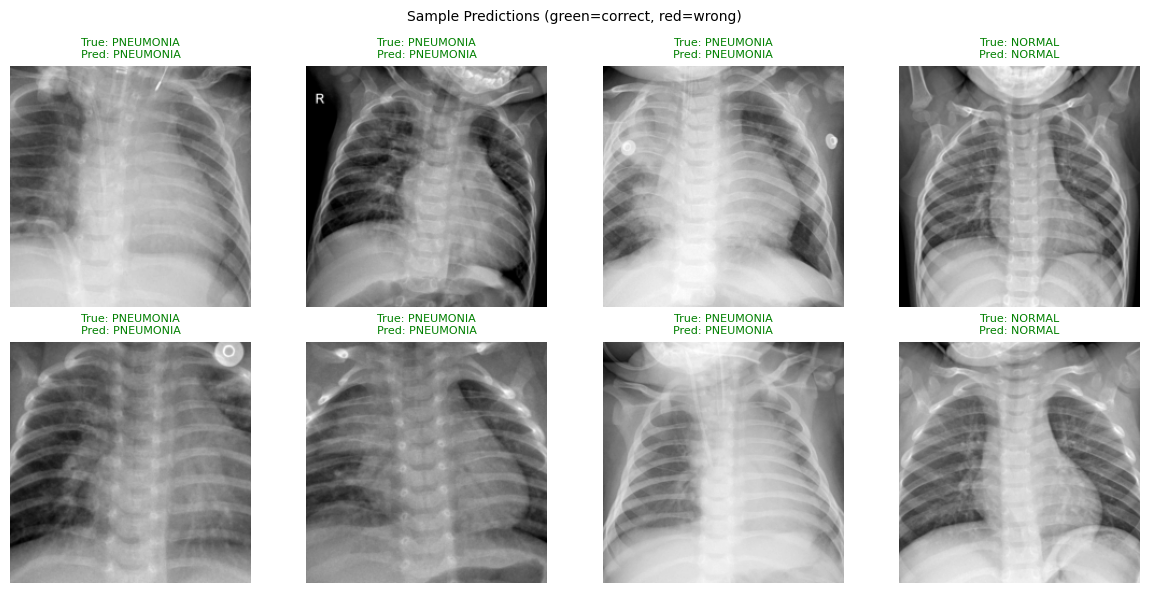


  Architecture: RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 98.6MB/s]


  Restored from checkpoint — redrawing figures without retraining.

              precision    recall  f1-score   support

      NORMAL       0.97      0.99      0.98       135
   PNEUMONIA       0.99      0.99      0.99       389

    accuracy                           0.99       524
   macro avg       0.98      0.99      0.99       524
weighted avg       0.99      0.99      0.99       524

  (checkpoint predates history saving — learning curve unavailable)


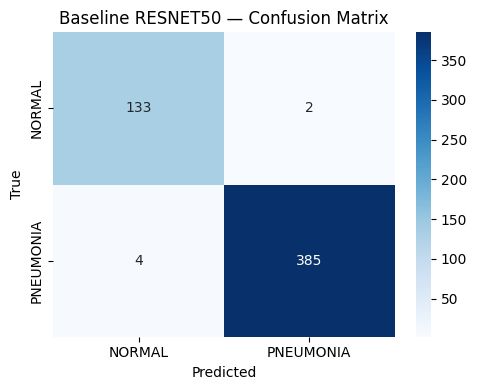

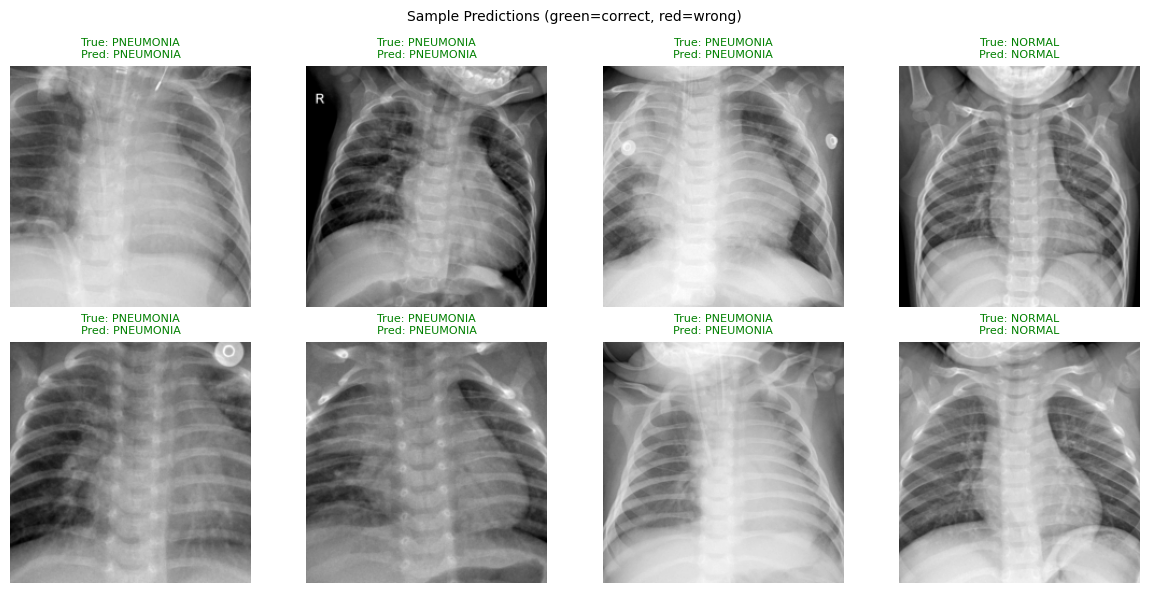


  Architecture: MOBILENET
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


  Restored from checkpoint — redrawing figures without retraining.

              precision    recall  f1-score   support

      NORMAL       0.98      0.96      0.97       135
   PNEUMONIA       0.99      0.99      0.99       389

    accuracy                           0.98       524
   macro avg       0.98      0.98      0.98       524
weighted avg       0.98      0.98      0.98       524

  (checkpoint predates history saving — learning curve unavailable)


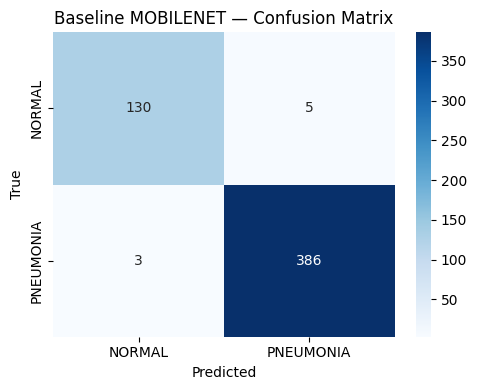

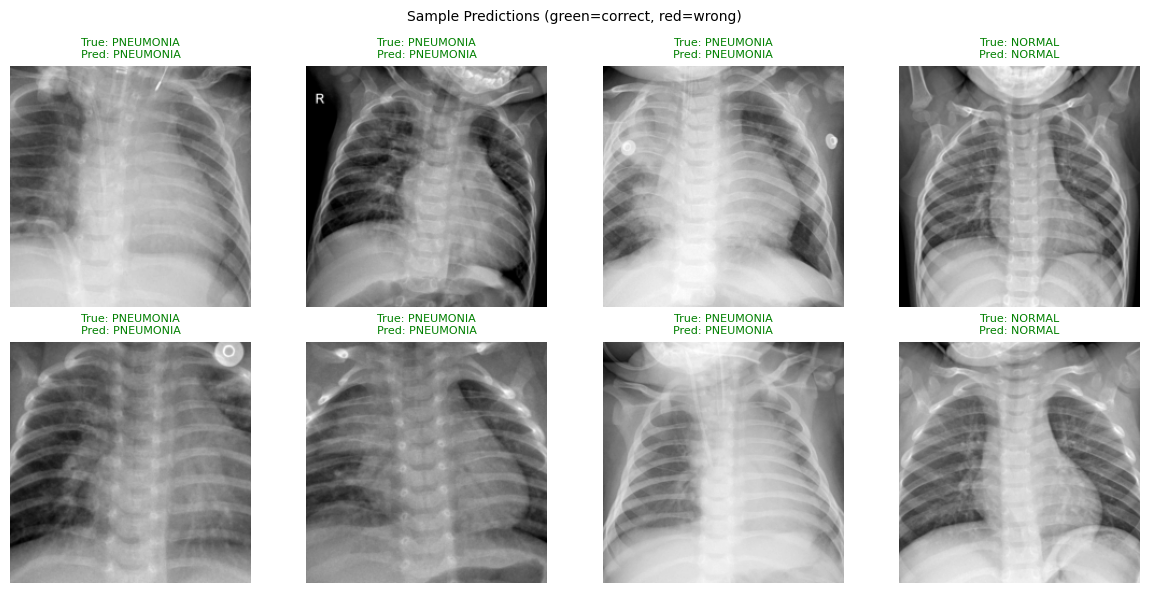

In [13]:
BASELINE_CONFIG = {
    "lr"          : 1e-4,
    "batch_size"  : 32,
    "weight_decay": 0.0,
    "optimizer"   : "adam",
    "num_epochs"  : 10,
}

bl_model = bl_loaders = None
bl_trained_arch = None

for ARCH in ["resnet18", "resnet50", "mobilenet"]:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    if is_done("Baseline", ARCH):
        # Training is skipped, but the thesis still needs this architecture's
        # figures — redraw them from the checkpoint rather than retraining.
        r_model, _, r_hist = load_best(f"baseline_{ARCH}")
        if r_model is None:
            print("  Skipped — logged earlier, but no model checkpoint to redraw from.")
            continue
        print("  Restored from checkpoint — redrawing figures without retraining.")
        r_loaders, _, _ = get_dataloaders(BASELINE_CONFIG["batch_size"])
        r_metrics       = evaluate_model(r_model, r_loaders["val"], CLASS_NAMES)
        print("\n" + r_metrics["report"])
        if r_hist:
            plot_training_history(r_hist, f"Baseline {ARCH.upper()}")
        else:
            print("  (checkpoint predates history saving — learning curve unavailable)")
        plot_confusion_matrix(r_metrics["cm"], CLASS_NAMES, f"Baseline {ARCH.upper()} — Confusion Matrix")
        show_sample_predictions(r_model, r_loaders["val"], CLASS_NAMES)
        bl_model, bl_loaders, bl_trained_arch = r_model, r_loaders, ARCH
        continue

    torch.manual_seed(SEED)
    bl_loaders, bl_sizes, CLASS_NAMES = get_dataloaders(BASELINE_CONFIG["batch_size"])

    bl_model      = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
    class_weights = compute_class_weights(bl_loaders['train'].dataset)
    bl_crit       = nn.CrossEntropyLoss(weight=class_weights)
    bl_opt        = torch.optim.Adam(bl_model.parameters(), lr=BASELINE_CONFIG["lr"])
    bl_sched      = lr_scheduler.StepLR(bl_opt, step_size=3, gamma=0.1)

    bl_model, bl_history = train_model(
        bl_model, bl_crit, bl_opt, bl_sched,
        bl_loaders, bl_sizes,
        num_epochs=BASELINE_CONFIG["num_epochs"],
        patience=5,
    )

    bl_metrics = evaluate_model(bl_model, bl_loaders["val"], CLASS_NAMES)
    log_result("Baseline", {**BASELINE_CONFIG, "arch": ARCH}, bl_metrics, bl_history["elapsed_s"])
    save_best(f"baseline_{ARCH}", bl_model, {**BASELINE_CONFIG, "arch": ARCH}, history=bl_history)
    bl_trained_arch = ARCH

    print("\n" + bl_metrics["report"])
    plot_training_history(bl_history, f"Baseline {ARCH.upper()}")
    plot_confusion_matrix(bl_metrics["cm"], CLASS_NAMES, f"Baseline {ARCH.upper()} — Confusion Matrix")
    show_sample_predictions(bl_model, bl_loaders["val"], CLASS_NAMES)

# ARCH now holds the last architecture of the loop — the representative Baseline
# model used by the ROC and Grad-CAM sections. Restore it if it was skipped here.
if bl_trained_arch != ARCH:
    bl_model, _, _   = load_best(f"baseline_{ARCH}")
    bl_loaders, _, _ = get_dataloaders(BASELINE_CONFIG["batch_size"])
    print(f"\nBaseline model ({ARCH.upper()}) restored from checkpoint.")

## 8. Experiment 2 — Grid Search

### Method
Grid Search exhaustively evaluates every combination of hyperparameter values from a predefined discrete grid. The number of trials equals the Cartesian product of all grid dimensions.

**Search space** (3 × 2 × 2 = **12 trials per architecture**, 36 in total):

| Hyperparameter | Values |
|---|---|
| Learning rate | 1e-3, 1e-4, 1e-5 |
| Batch size | 16, 32 |
| Weight decay | 0.0, 1e-4 |

### Limitation
Grid Search scales exponentially with the number of hyperparameters. It treats each parameter independently and cannot model interactions between them.

In [14]:
GRID = {
    "lr"          : [1e-3, 1e-4, 1e-5],
    "batch_size"  : [16, 32],
    "weight_decay": [0.0, 1e-4],
}

grid_keys   = list(GRID.keys())
grid_values = list(GRID.values())
grid_combos = list(product(*grid_values))
print(f"Grid Search: {len(grid_combos)} trials per architecture")

# Seed from the checkpoint so a resumed run does not overwrite a better model
# found in an earlier session with a weaker one from this session.
best_grid_acc     = best_logged_acc("GridSearch")
best_grid_config  = None
best_grid_model   = None
best_grid_arch    = None
best_grid_loaders = None

for ARCH in ["resnet18", "resnet50", "mobilenet"]:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    for trial_idx, combo in enumerate(grid_combos, 1):
        config = dict(zip(grid_keys, combo))
        print(f"\n[Grid {trial_idx}/{len(grid_combos)}] {config}")

        if is_done("GridSearch", ARCH, config):
            print("  Skipped — already completed in an earlier session.")
            continue

        torch.manual_seed(SEED)  # same seed for every trial → fair comparison
        gs_loaders, gs_sizes, _ = get_dataloaders(config["batch_size"])

        m             = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
        class_weights = compute_class_weights(gs_loaders['train'].dataset)
        crit          = nn.CrossEntropyLoss(weight=class_weights)
        opt           = torch.optim.Adam(m.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        sched         = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

        m, hist = train_model(
            m, crit, opt, sched,
            gs_loaders, gs_sizes,
            num_epochs=8, patience=3, verbose=False
        )
        metrics = evaluate_model(m, gs_loaders["val"], CLASS_NAMES)
        log_result("GridSearch", {**config, "num_epochs": 8, "optimizer": "adam", "arch": ARCH},
                   metrics, hist["elapsed_s"])

        print(f"  acc={metrics['accuracy']:.4f}  f1={metrics['f1']:.4f}  auc={metrics['roc_auc']:.4f}")

        if metrics["accuracy"] > best_grid_acc:
            best_grid_acc     = metrics["accuracy"]
            best_grid_config  = {**config, "arch": ARCH}
            best_grid_model   = copy.deepcopy(m)
            best_grid_arch    = ARCH
            best_grid_loaders = gs_loaders
            save_best("gridsearch", m, best_grid_config, history=hist)

# Every trial may have been restored from an earlier session, leaving no model
# in memory — reload the best one from disk for the downstream sections.
if best_grid_model is None:
    best_grid_model, best_grid_config, _ = load_best("gridsearch")
    if best_grid_model is None:
        raise RuntimeError("No Grid Search checkpoint found — run the search at least once.")
    best_grid_arch          = best_grid_config["arch"]
    best_grid_loaders, _, _ = get_dataloaders(best_grid_config["batch_size"])
    print("\nBest Grid Search model restored from checkpoint.")

print(f"\nBest Grid Search config : {best_grid_config}")
print(f"Best Grid Search val acc: {best_grid_acc:.4f}")

Grid Search: 12 trials per architecture

  Architecture: RESNET18

[Grid 1/12] {'lr': 0.001, 'batch_size': 16, 'weight_decay': 0.0}
  Skipped — already completed in an earlier session.

[Grid 2/12] {'lr': 0.001, 'batch_size': 16, 'weight_decay': 0.0001}
  Skipped — already completed in an earlier session.

[Grid 3/12] {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0}
  Skipped — already completed in an earlier session.

[Grid 4/12] {'lr': 0.001, 'batch_size': 32, 'weight_decay': 0.0001}
  Skipped — already completed in an earlier session.

[Grid 5/12] {'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.0}
  Skipped — already completed in an earlier session.

[Grid 6/12] {'lr': 0.0001, 'batch_size': 16, 'weight_decay': 0.0001}
  Skipped — already completed in an earlier session.

[Grid 7/12] {'lr': 0.0001, 'batch_size': 32, 'weight_decay': 0.0}
  Skipped — already completed in an earlier session.

[Grid 8/12] {'lr': 0.0001, 'batch_size': 32, 'weight_decay': 0.0001}
  Skipped — already

              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99       135
   PNEUMONIA       0.99      1.00      1.00       389

    accuracy                           0.99       524
   macro avg       0.99      0.99      0.99       524
weighted avg       0.99      0.99      0.99       524



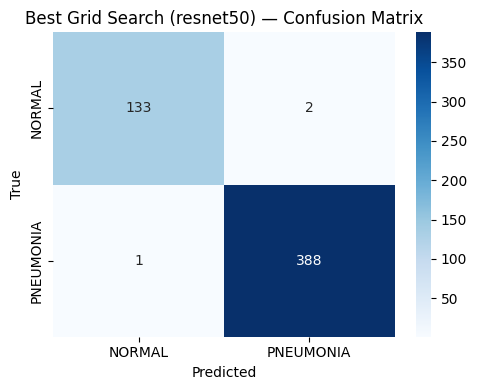

In [15]:
# Detailed report for the best Grid Search configuration
gs_best_metrics = evaluate_model(best_grid_model, best_grid_loaders["val"], CLASS_NAMES)
print(gs_best_metrics["report"])
plot_confusion_matrix(gs_best_metrics["cm"], CLASS_NAMES, f"Best Grid Search ({best_grid_arch}) — Confusion Matrix")

## 9. Experiment 3  Hyperopt (Bayesian Optimization with TPE)

### Method
Hyperopt uses the **Tree of Parzen Estimators (TPE)** algorithm a Bayesian optimization method. Unlike Grid Search, TPE:
- Models the probability distribution of good vs bad configurations based on past trials
- Focuses sampling in promising regions of the search space
- Handles continuous parameters (e.g., `lr` on a log scale) natively

**Search space** (**20 trials**, larger continuous space):

| Hyperparameter | Distribution |
|---|---|
| Learning rate | Log-uniform in [1e-5, 1e-2] |
| Batch size | Choice: {16, 32, 64} |
| Weight decay | Log-uniform in [1e-6, 1e-2] |
| Optimizer | Choice: {Adam, SGD with momentum} |

The objective function returns the **negative ROC-AUC** (Hyperopt minimizes), which is a more robust metric than accuracy for imbalanced medical data.

### Budget
Twenty evaluations are run **per architecture**, 60 in total.

### Warm-up length
`tpe.suggest` samples its first `n_startup_jobs` trials at random before the Parzen
estimators have enough data to model the search space. The library default is 20, so a
20-evaluation budget would spend *every* trial on random warm-up and never invoke the
Bayesian machinery at all.

In [9]:
# tpe.suggest draws its first n_startup_jobs trials at random before the Parzen
# estimators have enough observations to model the space; the library default is
# 20. With max_evals=20 that means every single trial is a random draw and TPE is never actually used.
# Warming up on 5 trials leaves 15 genuinely Bayesian ones at the same total cost.
TPE_STARTUP_JOBS = 5
HYPEROPT_MAX_EVALS = 20

ho_trials_per_arch      = {}
best_ho_params_per_arch = {}
BEST_HO_ARCH            = None
best_ho_auc             = 0.0

HYPEROPT_SPACE = {
    "lr"          : hp.loguniform("lr",           np.log(1e-5), np.log(1e-2)),
    "batch_size"  : hp.choice("batch_size",       [16, 32, 64]),
    "weight_decay": hp.loguniform("weight_decay", np.log(1e-6), np.log(1e-2)),
    "optimizer"   : hp.choice("optimizer",        ["adam", "sgd"]),
}

ARCH_LIST_HO = ["resnet18", "resnet50", "mobilenet"]
for ARCH in ARCH_LIST_HO:
    print(f"\n{'='*55}")
    print(f"  Architecture: {ARCH.upper()}")
    print(f"{'='*55}")

    def hyperopt_objective(params: dict) -> dict:
        torch.manual_seed(SEED)

        ho_loaders, ho_sizes, _ = get_dataloaders(params["batch_size"])
        m             = build_model(arch_name=ARCH, num_classes=len(CLASS_NAMES))
        class_weights = compute_class_weights(ho_loaders['train'].dataset)
        crit          = nn.CrossEntropyLoss(weight=class_weights)

        if params["optimizer"] == "adam":
            opt = torch.optim.Adam(
                m.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
            )
        else:
            opt = torch.optim.SGD(
                m.parameters(), lr=params["lr"], momentum=0.9,
                weight_decay=params["weight_decay"]
            )

        sched = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)
        m, hist = train_model(
            m, crit, opt, sched,
            ho_loaders, ho_sizes,
            num_epochs=8, patience=3, verbose=False
        )
        metrics = evaluate_model(m, ho_loaders["val"], CLASS_NAMES)

        log_result(
            "Hyperopt",
            {**params, "num_epochs": 8, "arch": ARCH},
            metrics,
            hist["elapsed_s"],
        )
        print(f"  lr={params['lr']:.2e}  bs={params['batch_size']}  "
              f"wd={params['weight_decay']:.2e}  opt={params['optimizer']}  "
              f"\u2192 auc={metrics['roc_auc']:.4f}")

        # Minimise negative AUC (more robust than accuracy for imbalanced data)
        return {"loss": -metrics["roc_auc"], "status": STATUS_OK}

    trials_path = f"{CKPT_DIR}/hyperopt_trials_{ARCH}_s{TPE_STARTUP_JOBS}.pkl"
    if os.path.exists(trials_path):
        with open(trials_path, "rb") as f:
            ho_trials = pickle.load(f)
        best_ho_params = ho_trials.argmin
        print(f"Restored {len(ho_trials.trials)} trials for {ARCH} from checkpoint.")
    else:
        results_log[:] = [
            r for r in results_log
            if not (r.get("method") == "Hyperopt" and r.get("arch") == ARCH)
        ]
        ho_trials = Trials()
        best_ho_params = fmin(
            fn=hyperopt_objective,
            space=HYPEROPT_SPACE,
            algo=partial(tpe.suggest, n_startup_jobs=TPE_STARTUP_JOBS),
            max_evals=HYPEROPT_MAX_EVALS,
            trials=ho_trials,
            rstate=np.random.default_rng(SEED),
        )
        with open(trials_path, "wb") as f:
            pickle.dump(ho_trials, f)
    print("\nBest Hyperopt raw params:", best_ho_params)

    ho_trials_per_arch[ARCH]      = ho_trials
    best_ho_params_per_arch[ARCH] = best_ho_params
    arch_best_auc = -ho_trials.best_trial["result"]["loss"]
    if arch_best_auc > best_ho_auc:
        best_ho_auc  = arch_best_auc
        BEST_HO_ARCH = ARCH

print(f"\nOverall best Hyperopt — arch={BEST_HO_ARCH}  auc={best_ho_auc:.4f}")
# Verification block — guards against the double-run that contaminated run1
print("\nHyperopt Trials Verification:")
ho_counts = {}
for r in results_log:
    if r.get("method") == "Hyperopt":
        a = r.get("arch")
        ho_counts[a] = ho_counts.get(a, 0) + 1

total_ho = 0
for a in ARCH_LIST_HO:
    count = ho_counts.get(a, 0)
    print(f"  {a}: {count} trials")
    total_ho += count
    assert count == HYPEROPT_MAX_EVALS, (
        f"Architecture {a} has {count} Hyperopt trials, expected {HYPEROPT_MAX_EVALS}."
    )

expected_total = HYPEROPT_MAX_EVALS * len(ARCH_LIST_HO)
assert total_ho == expected_total, (
    f"Total Hyperopt trials {total_ho}, expected {expected_total}."
)
print("Verification passed.")
# Aliases for the reconstruction cell
ho_trials      = ho_trials_per_arch[BEST_HO_ARCH]
best_ho_params = best_ho_params_per_arch[BEST_HO_ARCH]


  Architecture: RESNET18
  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

ERROR:hyperopt.fmin:job exception: name 'get_dataloaders' is not defined


  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]


NameError: name 'get_dataloaders' is not defined

Best Hyperopt config: {'lr': 0.0007128243944571563, 'batch_size': 16, 'weight_decay': 3.871249382938917e-06, 'optimizer': 'adam'}
Best Hyperopt architecture: mobilenet
Epoch 1/10  --------------------
  train  loss=0.1885  acc=0.9295
  val    loss=0.0874  acc=0.9676
Epoch 2/10  --------------------
  train  loss=0.1160  acc=0.9558
  val    loss=0.0693  acc=0.9733
Epoch 3/10  --------------------
  train  loss=0.1048  acc=0.9620
  val    loss=0.0533  acc=0.9676
Epoch 4/10  --------------------
  train  loss=0.0658  acc=0.9768
  val    loss=0.0364  acc=0.9905
Epoch 5/10  --------------------
  train  loss=0.0491  acc=0.9819
  val    loss=0.0342  acc=0.9847
Epoch 6/10  --------------------
  train  loss=0.0482  acc=0.9834
  val    loss=0.0342  acc=0.9885
Epoch 7/10  --------------------
  train  loss=0.0406  acc=0.9868
  val    loss=0.0320  acc=0.9905
Epoch 8/10  --------------------
  train  loss=0.0347  acc=0.9885
  val    loss=0.0298  acc=0.9885
Epoch 9/10  --------------------
  train

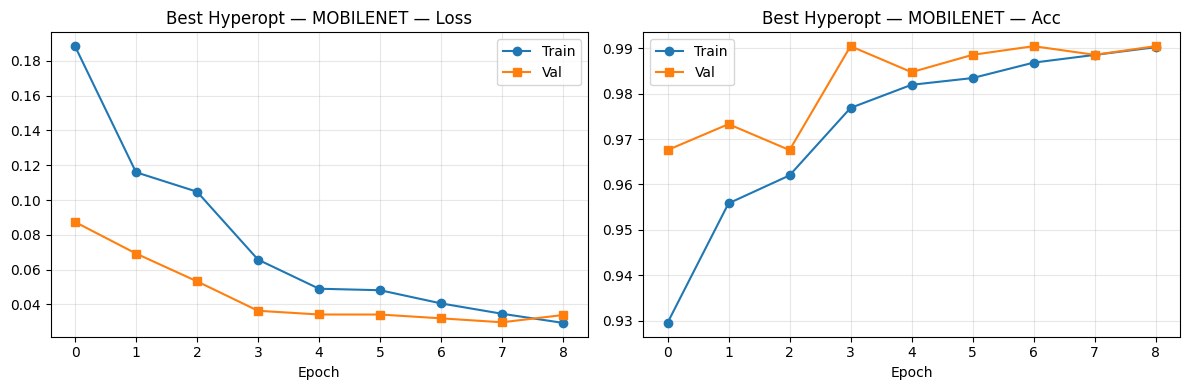

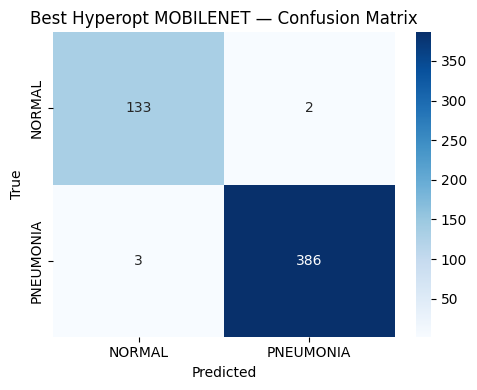

In [17]:
# Reconstruct and fully evaluate the best Hyperopt model
best_ho_trial = ho_trials.best_trial["result"]
best_ho_idx   = ho_trials.best_trial["tid"]
best_ho_vals  = ho_trials.trials[best_ho_idx]["misc"]["vals"]

# hp.choice returns index — decode back to actual values
bs_choices  = [16, 32, 64]
opt_choices = ["adam", "sgd"]
best_ho_config = {
    "lr"          : float(best_ho_vals["lr"][0]),
    "batch_size"  : bs_choices[int(best_ho_vals["batch_size"][0])],
    "weight_decay": float(best_ho_vals["weight_decay"][0]),
    "optimizer"   : opt_choices[int(best_ho_vals["optimizer"][0])],
}
print("Best Hyperopt config:", best_ho_config)
print("Best Hyperopt architecture:", BEST_HO_ARCH)

torch.manual_seed(SEED)
ho_best_loaders, ho_best_sizes, _ = get_dataloaders(best_ho_config["batch_size"])
ho_best_model = build_model(arch_name=BEST_HO_ARCH, num_classes=len(CLASS_NAMES))
class_weights = compute_class_weights(ho_best_loaders['train'].dataset)
ho_best_crit  = nn.CrossEntropyLoss(weight=class_weights)

if best_ho_config["optimizer"] == "adam":
    ho_best_opt = torch.optim.Adam(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], weight_decay=best_ho_config["weight_decay"]
    )
else:
    ho_best_opt = torch.optim.SGD(
        ho_best_model.parameters(),
        lr=best_ho_config["lr"], momentum=0.9, weight_decay=best_ho_config["weight_decay"]
    )

ho_best_sched = lr_scheduler.StepLR(ho_best_opt, step_size=3, gamma=0.1)
ho_best_model, ho_best_hist = train_model(
    ho_best_model, ho_best_crit, ho_best_opt, ho_best_sched,
    ho_best_loaders, ho_best_sizes,
    num_epochs=10, patience=5,
)

ho_best_metrics = evaluate_model(ho_best_model, ho_best_loaders["val"], CLASS_NAMES)
print("\n" + ho_best_metrics["report"])
plot_training_history(ho_best_hist, f"Best Hyperopt — {BEST_HO_ARCH.upper()}")
plot_confusion_matrix(ho_best_metrics["cm"], CLASS_NAMES, f"Best Hyperopt {BEST_HO_ARCH.upper()} — Confusion Matrix")

## 10. Results Comparison

Summary of all experiments across the three optimization strategies. A higher ROC-AUC is the primary success criterion because it is threshold-independent and robust to class imbalance.

In [18]:
results_df = pd.DataFrame(results_log)
results_df.to_csv(f"{OUT_DIR}/experiment_results.csv", index=False)
print(f"Saved {len(results_df)} experiment rows \u2192 experiment_results.csv\n")

# Summary by method mean and max of key metrics
summary = (
    results_df
    .groupby(["arch", "method"])[["val_accuracy", "val_f1", "val_roc_auc"]]
    .agg(["mean", "max"])
    .round(4)
)
print(summary)

Saved 159 experiment rows → experiment_results.csv

                     val_accuracy          val_f1         val_roc_auc        
                             mean     max    mean     max        mean     max
arch      method                                                             
mobilenet Baseline         0.9847  0.9847  0.9847  0.9847      0.9986  0.9986
          GridSearch       0.9572  0.9905  0.9587  0.9905      0.9955  0.9994
          Hyperopt         0.9448  0.9924  0.9471  0.9924      0.9894  0.9993
resnet18  Baseline         0.9885  0.9885  0.9885  0.9885      0.9991  0.9991
          GridSearch       0.9817  0.9885  0.9818  0.9886      0.9982  0.9992
          Hyperopt         0.9579  0.9905  0.9594  0.9905      0.9939  0.9996
resnet50  Baseline         0.9885  0.9885  0.9886  0.9886      0.9959  0.9959
          GridSearch       0.9822  0.9943  0.9823  0.9943      0.9976  0.9994
          Hyperopt         0.9663  0.9924  0.9669  0.9924      0.9930  0.9993


NameError: name 'results_df' is not defined

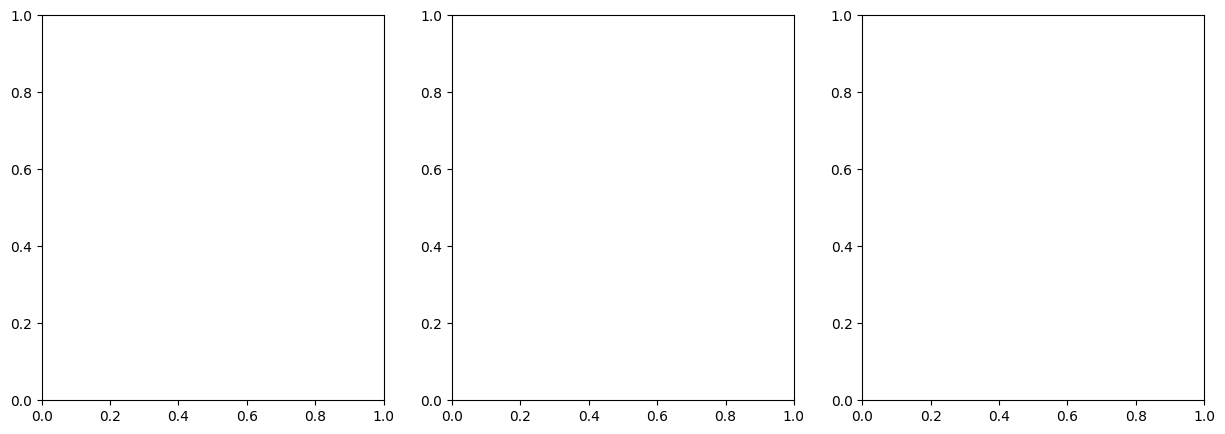

In [11]:
# Visual comparison of metrics across methods and architectures
ARCHS   = ["resnet18", "resnet50", "mobilenet"]
METHODS = ["Baseline", "GridSearch", "Hyperopt"]
METRICS = ["val_accuracy", "val_f1", "val_roc_auc"]
MTITLES = ["Accuracy", "Weighted F1", "ROC-AUC"]

# Figure 1 method overview aggregated across all architectures
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, title in zip(axes, METRICS, MTITLES):
    present = [m for m in METHODS if m in results_df["method"].values]
    data    = [results_df.loc[results_df["method"] == m, metric].values for m in present]
    labels  = [f"{m} (n={len(d)})" for m, d in zip(present, data)]
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(f"{title} — all architectures")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
plt.suptitle("Hyperparameter Optimization Method Comparison (all architectures combined) \n(Note: groups have unequal numbers of trials)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/comparison_boxplots.png", dpi=150)
plt.show()

# Figure 2 — per-architecture breakdown
fig, axes = plt.subplots(len(ARCHS), len(METRICS), figsize=(15, 12))
for row, arch in enumerate(ARCHS):
    df_arch = results_df[results_df["arch"] == arch]
    for col, (metric, title) in enumerate(zip(METRICS, MTITLES)):
        ax = axes[row][col]
        present = [m for m in METHODS if m in df_arch["method"].values]
        data    = [df_arch.loc[df_arch["method"] == m, metric].values for m in present]
        labels  = [f"{m} (n={len(d)})" for m, d in zip(present, data)]
        ax.boxplot(data, tick_labels=labels)
        ax.set_title(f"{arch} — {title}")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
plt.suptitle("Method Comparison per Architecture \n(Note: groups have unequal numbers of trials)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/comparison_boxplots_per_arch.png", dpi=150)
plt.show()
print("Figures saved → comparison_boxplots.png, comparison_boxplots_per_arch.png")


In [20]:
# Best configuration per arch/method
best_per_method = (
    results_df
    .sort_values("val_roc_auc", ascending=False)
    .groupby(["arch", "method"])
    .first()[["lr", "batch_size", "weight_decay", "optimizer",
               "val_accuracy", "val_f1", "val_roc_auc", "elapsed_s"]]
)
print("Best configuration per arch/method (by ROC-AUC):")
print(best_per_method.to_string())

Best configuration per arch/method (by ROC-AUC):
                            lr  batch_size  weight_decay optimizer  val_accuracy  val_f1  val_roc_auc  elapsed_s
arch      method                                                                                                
mobilenet Baseline    0.000100          32      0.000000      adam        0.9847  0.9847       0.9986      223.9
          GridSearch  0.001000          16      0.000000      adam        0.9905  0.9905       0.9994      188.2
          Hyperopt    0.000713          16      0.000004      adam        0.9905  0.9905       0.9993      173.2
resnet18  Baseline    0.000100          32      0.000000      adam        0.9885  0.9885       0.9991      194.7
          GridSearch  0.001000          32      0.000000      adam        0.9828  0.9828       0.9992      101.4
          Hyperopt    0.000672          64      0.000014      adam        0.9885  0.9886       0.9996      153.8
resnet50  Baseline    0.000100          32     

In [21]:
# Save all results as JSON for reproducibility / thesis appendix
with open(f"{OUT_DIR}/experiment_results.json", "w") as f:
    json.dump(results_log, f, indent=2)
print("Results also saved → experiment_results.json")

Results also saved → experiment_results.json


/tmp/ipykernel_1880/3025153706.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", fontsize=8)


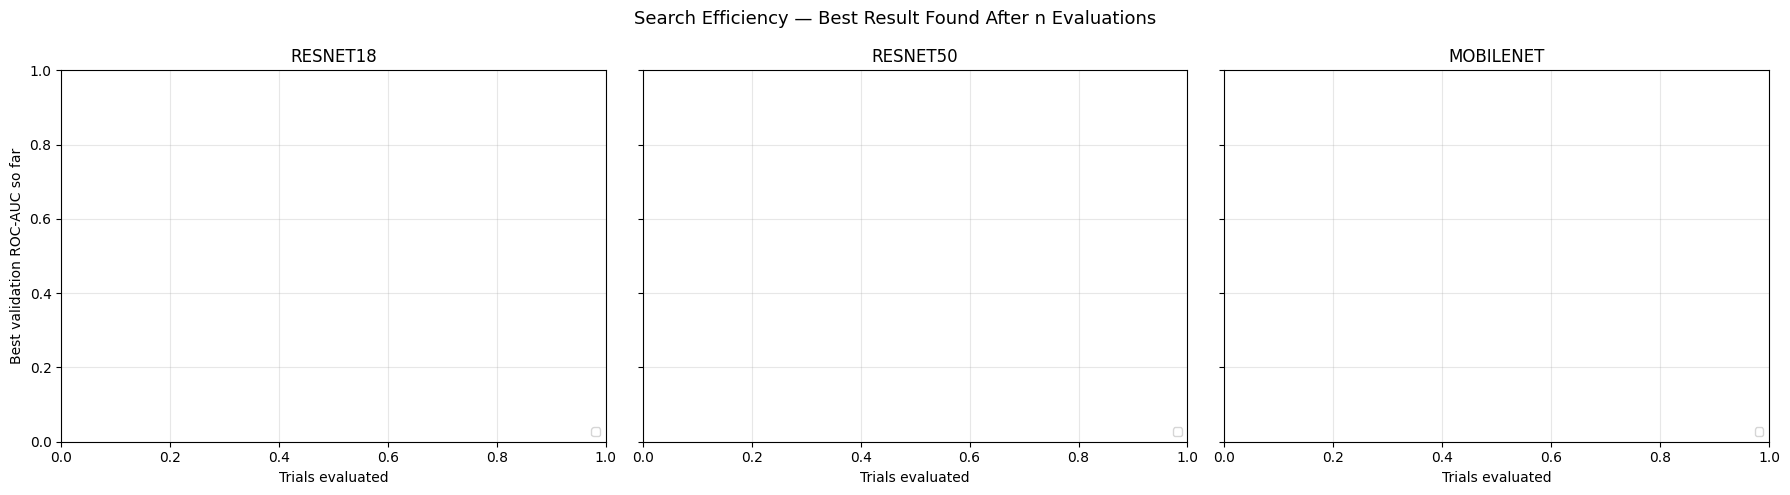

Total search cost (all architectures, wall clock):

Saved → /content/drive/MyDrive/magisterka_checkpoints/run2/outputs/search_convergence.png


NameError: name 'results_df' is not defined

In [10]:
# Search efficiency the central question when comparing Grid Search with TPE.
# For each method the curve shows the best validation ROC-AUC found so far after n
# trials, so a method that climbs faster is finding good configurations from fewer
# evaluations. results_log preserves insertion order, so filtering it by
# (architecture, method) recovers each search in the order it was actually run.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, arch_c in zip(axes, ["resnet18", "resnet50", "mobilenet"]):
    for method_c in ["GridSearch", "Hyperopt"]:
        aucs = [r["val_roc_auc"] for r in results_log
                if r.get("arch") == arch_c and r.get("method") == method_c]
        if not aucs:
            continue
        best_so_far = np.maximum.accumulate(aucs)
        ax.plot(range(1, len(best_so_far) + 1), best_so_far,
                marker="o", markersize=3, lw=1.8, label=f"{method_c} ({len(aucs)} trials)")

    base = [r["val_roc_auc"] for r in results_log
            if r.get("arch") == arch_c and r.get("method") == "Baseline"]
    if base:
        ax.axhline(base[0], color="grey", ls="--", lw=1.2,
                   label=f"Baseline (1 trial, {base[0]:.4f})")

    ax.set_title(arch_c.upper(), fontsize=12)
    ax.set_xlabel("Trials evaluated", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

axes[0].set_ylabel("Best validation ROC-AUC so far", fontsize=10)
plt.suptitle("Search Efficiency — Best Result Found After n Evaluations", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/search_convergence.png", dpi=150)
plt.show()

# Total search cost per method the other half of the comparison
cost = {}
for r in results_log:
    cost[r["method"]] = cost.get(r["method"], 0.0) + r.get("elapsed_s", 0.0)
print("Total search cost (all architectures, wall clock):")
for m, sec in sorted(cost.items(), key=lambda kv: -kv[1]):
    n = sum(1 for r in results_log if r["method"] == m)
    print(f"  {m:12s} {n:3d} trials   {sec/60:7.1f} min   ({sec/max(n,1):6.1f} s/trial)")
print(f"\nSaved → {OUT_DIR}/search_convergence.png")

cost_rows = []
for method in ['Baseline', 'GridSearch', 'Hyperopt']:
    sub = results_df[results_df['method'] == method]
    if len(sub) == 0:
        continue
    cost_rows.append({
        'method'        : method,
        'trials'        : len(sub),
        'total_minutes' : round(sub['elapsed_s'].sum() / 60, 1),
        'mean_s_per_trial': round(sub['elapsed_s'].mean(), 1),
    })

cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(f"{OUT_DIR}/search_cost.csv", index=False)
print(f"\nSaved → {OUT_DIR}/search_cost.csv")
print(cost_df.to_string(index=False))

# --- Matched Budget Comparison ---
matched_budget_rows = []
for arch_c in ["resnet18", "resnet50", "mobilenet"]:
    gs_aucs = [r["val_roc_auc"] for r in results_log if r.get("arch") == arch_c and r.get("method") == "GridSearch"]
    ho_aucs = [r["val_roc_auc"] for r in results_log if r.get("arch") == arch_c and r.get("method") == "Hyperopt"]

    if not gs_aucs or not ho_aucs:
        continue

    budget = len(gs_aucs)
    gs_best = max(gs_aucs)

    if len(ho_aucs) >= budget:
        ho_best = max(ho_aucs[:budget])
    else:
        ho_best = max(ho_aucs)

    if gs_best > ho_best:
        winner = "GridSearch"
    elif ho_best > gs_best:
        winner = "Hyperopt"
    else:
        winner = "Tie"

    matched_budget_rows.append({
        "arch": arch_c,
        "budget": budget,
        "gridsearch_best": gs_best,
        "hyperopt_best": ho_best,
        "winner": winner
    })

if matched_budget_rows:
    matched_df = pd.DataFrame(matched_budget_rows)
    print("\nMatched Budget Comparison (Best ROC-AUC after B trials):")
    print(matched_df.to_string(index=False))


## 11. Final Evaluation Under a Common Protocol

The three searches are not directly comparable as they stand. Grid Search and Hyperopt
evaluated their candidates for 8 epochs while the Baseline ran for 10, and each method's
single best result landed on a different architecture. Comparing those runs head to head
would confound three separate effects the optimization method, the architecture, and the
training budget and any conclusion drawn from such a comparison would be unsound.

This section removes both confounds:

- **Equal training budget.** For every (architecture, method) pair, the best configuration
  found during that method's search is retrained from scratch under one identical protocol:
  the same number of epochs, the same early-stopping patience, and the same seed.
- **Comparison within a fixed architecture.** Methods are compared against each other on the
  same architecture, which isolates the effect of the optimization method. Repeating this
  across all three architectures also shows whether the ranking between methods is stable
  or an artefact of one particular network.
- **Held-out test split.** All numbers reported here come from the 624-image test split,
  which no part of the hyperparameter search has seen. The validation split was used to
  *select* configurations, so validation metrics are optimistically biased and are reported
  alongside only for reference.

In [7]:
# One protocol for every finalist, so differences reflect the method and nothing else.
FINAL_EPOCHS   = 15
FINAL_PATIENCE = 3
FINAL_SEEDS    = [42, 1337, 2024]

ARCH_LIST = ["resnet18", "resnet50", "mobilenet"]
METHODS   = ["Baseline", "GridSearch", "Hyperopt"]

# Guard: this cell needs the search results from cells 20 / 22 / 25.
if not results_log and os.path.exists(RESULTS_CKPT):
    restore_results()
if not results_log:
    raise RuntimeError("results_log is empty — run the search cells first.")


def best_config_for(arch: str, method: str) -> dict | None:
    """Best configuration this method found for this architecture, by validation ROC-AUC."""
    rows = [r for r in results_log if r.get("arch") == arch and r.get("method") == method]
    if not rows:
        return None
    b = max(rows, key=lambda r: r["val_roc_auc"])
    return {
        "lr"          : float(b["lr"]),
        "batch_size"  : int(b["batch_size"]),
        "weight_decay": float(b.get("weight_decay", 0.0)),
        "optimizer"   : b.get("optimizer", "adam"),
    }


def build_optimizer(model: nn.Module, cfg: dict):
    if cfg["optimizer"] == "adam":
        return torch.optim.Adam(
            model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
        )
    return torch.optim.SGD(
        model.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=cfg["weight_decay"]
    )


final_models = {}   # (arch, method) -> (model, loaders, history)  — first seed only
final_rows   = []

for seed in FINAL_SEEDS:
    print(f"\n{'='*78}")
    print(f"SEED {seed}")
    print(f"{'='*78}")

    for arch_f in ARCH_LIST:
        for method_f in METHODS:
            cfg = best_config_for(arch_f, method_f)
            if cfg is None:
                print(f"[{arch_f.upper()} / {method_f}] no search results — skipped")
                continue

            print(f"\n[{arch_f.upper()} / {method_f}]  seed={seed}  {cfg}")
            tag = f"final_{arch_f}_{method_f}_s{seed}"

            # Seed BEFORE the dataloaders so shuffling depends on it too.
            set_seed(seed)
            model, _, hist = load_best(tag)
            loaders, sizes, _ = get_dataloaders(cfg["batch_size"])

            if model is None:
                set_seed(seed)
                model = build_model(arch_name=arch_f, num_classes=len(CLASS_NAMES))
                crit  = nn.CrossEntropyLoss(
                    weight=compute_class_weights(loaders["train"].dataset))
                opt   = build_optimizer(model, cfg)
                sched = lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)
                model, hist = train_model(
                    model, crit, opt, sched, loaders, sizes,
                    num_epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE, verbose=False,
                )
                save_best(tag, model,
                          {**cfg, "arch": arch_f, "method": method_f, "seed": seed},
                          history=hist)
            else:
                print("  Restored from checkpoint.")

            val_m  = evaluate_model(model, loaders["val"],  CLASS_NAMES)
            test_m = evaluate_model(model, loaders["test"], CLASS_NAMES)

            # Downstream cells (36, 38, 40, 42) use one seed only, for consistency.
            if seed == FINAL_SEEDS[0]:
                final_models[(arch_f, method_f)] = (model, loaders, hist)

            final_rows.append({
                "seed": seed, "arch": arch_f, "method": method_f, **cfg,
                "val_accuracy" : round(val_m["accuracy"], 4),
                "val_f1"       : round(val_m["f1"],       4),
                "val_roc_auc"  : round(val_m["roc_auc"],  4),
                "test_accuracy": round(test_m["accuracy"], 4),
                "test_f1"      : round(test_m["f1"],       4),
                "test_roc_auc" : round(test_m["roc_auc"],  4),
            })
            print(f"  val   acc={val_m['accuracy']:.4f}  auc={val_m['roc_auc']:.4f}")
            print(f"  TEST  acc={test_m['accuracy']:.4f}  "
                  f"f1={test_m['f1']:.4f}  auc={test_m['roc_auc']:.4f}")

final_df = pd.DataFrame(final_rows)
final_df.to_csv(f"{OUT_DIR}/final_evaluation_seeds.csv", index=False)

print("\n" + "=" * 78)
print("FINAL COMPARISON ACROSS SEEDS — held-out test split (624 images)")
print("=" * 78)

final_summary = (
    final_df.groupby(["arch", "method"])[["test_accuracy", "test_f1", "test_roc_auc"]]
    .agg(["mean", "std"])
    .round(4)
)
print(final_summary.to_string())
final_summary.to_csv(f"{OUT_DIR}/final_summary_seeds.csv")

print(f"\nSaved → {OUT_DIR}/final_evaluation_seeds.csv")
print(f"Saved → {OUT_DIR}/final_summary_seeds.csv")


EVALUATING WITH SEED: 42


NameError: name 'results_log' is not defined

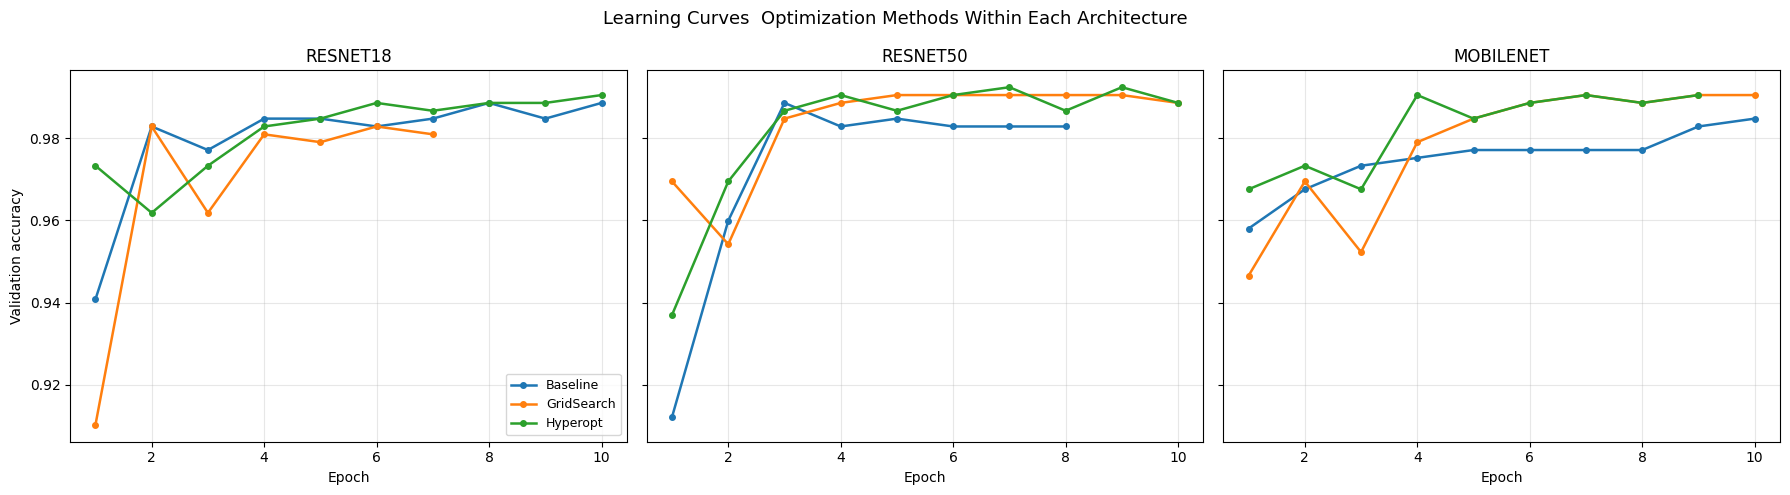

Saved → final_learning_curves.png


In [24]:
def plot_final_loss_curves(models_dict, arch_list):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    colors = {'Baseline': 'tab:blue', 'GridSearch': 'tab:orange', 'Hyperopt': 'tab:green'}
    for ax, arch_f in zip(axes, arch_list):
        for method_f in METHODS:
            entry = models_dict.get((arch_f, method_f))
            if entry is None:
                continue
            _, _, hist = entry
            if not hist or "train_loss" not in hist or "val_loss" not in hist:
                continue
            epochs = range(1, len(hist["train_loss"]) + 1)
            ax.plot(epochs, hist["train_loss"], color=colors[method_f], ls="--", lw=1.8, label=f"{method_f} (Train)")
            ax.plot(epochs, hist["val_loss"], color=colors[method_f], marker="o", markersize=4, ls="-", lw=1.8, label=f"{method_f} (Val)")
        ax.set_title(arch_f.upper(), fontsize=12)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Loss", fontsize=10)
    # Create a custom legend for line styles
    import matplotlib.lines as mlines
    solid_line = mlines.Line2D([], [], color='black', marker='o', markersize=4, ls='-', label='Validation Loss')
    dashed_line = mlines.Line2D([], [], color='black', ls='--', label='Training Loss')
    # also get the method colors
    method_lines = [mlines.Line2D([], [], color=colors[m], lw=2, label=m) for m in METHODS if m in colors]
    axes[0].legend(handles=[solid_line, dashed_line] + method_lines, fontsize=9)

    plt.suptitle("Loss Curves (Training vs Validation) Within Each Architecture", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/final_loss_curves.png", dpi=150)
    plt.show()
    print(f"Saved → {OUT_DIR}/final_loss_curves.png")


# Learning curves per architecture — the three methods overlaid, so the effect of the
# optimization method is visible directly rather than spread across separate figures.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, arch_f in zip(axes, ARCH_LIST):
    for method_f in METHODS:
        entry = final_models.get((arch_f, method_f))
        if entry is None:
            continue
        _, _, hist = entry
        if not hist:
            continue
        epochs = range(1, len(hist["val_acc"]) + 1)
        ax.plot(epochs, hist["val_acc"], marker="o", markersize=4, lw=1.8, label=method_f)
    ax.set_title(arch_f.upper(), fontsize=12)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Validation accuracy", fontsize=10)
axes[0].legend(fontsize=9)
plt.suptitle("Learning Curves  Optimization Methods Within Each Architecture", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/final_learning_curves.png", dpi=150)
plt.show()
print("Saved → final_learning_curves.png")

plot_final_loss_curves(final_models, ARCH_LIST)


In [25]:
# =============================================================================
# Przedzialy ufnosci i test istotnosci dla roznic ROC-AUC na zbiorze testowym.
#
# Wklej jako NOWA KOMORKE, PO uruchomieniu sekcji 11 (final_models).
# Nie trenuje niczego - tylko przepuszcza gotowe modele przez zbior testowy.
# =============================================================================
import numpy as np
import torch
import pandas as pd
from sklearn.metrics import roc_auc_score
from itertools import combinations

# --- 0. Zaleznosci -----------------------------------------------------------
if "final_models" not in dir() or not final_models:
    raise RuntimeError(
        "Brak final_models. Uruchom komorki notatnika od gory do sekcji 11 "
        "wlacznie. Modele wczytaja sie z checkpointow, wiec pojdzie szybko."
    )

SEED    = globals().get("SEED", 42)
OUT_DIR = globals().get("OUT_DIR", ".")
DEV     = globals().get("device", None) or torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

N_BOOT = 2000
rng = np.random.default_rng(SEED)


def get_scores(model, dataloader):
    """Zwraca (prawdopodobienstwa klasy PNEUMONIA, etykiety prawdziwe)."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for inputs, y in dataloader:
            p = torch.softmax(model(inputs.to(DEV)), dim=1)[:, 1]
            probs.append(p.cpu().numpy())
            labels.append(np.asarray(y).ravel())
    return np.concatenate(probs), np.concatenate(labels)


# --- 1. Predykcje wszystkich finalnych modeli --------------------------------
scores, y_true = {}, None
for (arch, method), bundle in final_models.items():
    model, loaders = bundle[0], bundle[1]
    model.to(DEV)
    p, y = get_scores(model, loaders["test"])
    scores[(arch, method)] = p
    if y_true is None:
        y_true = y
    elif not np.array_equal(y_true, y):
        raise RuntimeError(f"Inna kolejnosc probek dla {arch}/{method} "
                           "- sprawdz, czy test loader ma shuffle=False")

n = len(y_true)
print(f"Zbior testowy: {n} obrazow, {int(y_true.sum())} PNEUMONIA, "
      f"{n - int(y_true.sum())} NORMAL")
print(f"Modeli do porownania: {len(scores)}\n")

# --- 2. Bootstrap ------------------------------------------------------------
idx_boot = rng.integers(0, n, size=(N_BOOT, n))
keep = np.array([len(np.unique(y_true[i])) == 2 for i in idx_boot])
idx_boot = idx_boot[keep]

boot = {k: np.array([roc_auc_score(y_true[i], p[i]) for i in idx_boot])
        for k, p in scores.items()}
obs = {k: roc_auc_score(y_true, p) for k, p in scores.items()}

print("=" * 76)
print("ROC-AUC z 95% przedzialem ufnosci (bootstrap)")
print("=" * 76)
for k in sorted(scores):
    v = boot[k]
    print(f"{k[0]:10s} {k[1]:12s}  AUC = {obs[k]:.4f}"
          f"   95% CI = [{np.percentile(v, 2.5):.4f}, {np.percentile(v, 97.5):.4f}]")

# --- 3. Sparowane roznice miedzy metodami ------------------------------------
print("\n" + "=" * 76)
print("ROZNICE MIEDZY METODAMI (bootstrap sparowany)")
print("CI roznicy zawiera 0  ->  roznica nieistotna statystycznie")
print("=" * 76)

rows = []
for arch in sorted({k[0] for k in scores}):
    met = sorted(k[1] for k in scores if k[0] == arch)
    for m1, m2 in combinations(met, 2):
        d = boot[(arch, m1)] - boot[(arch, m2)]
        lo, hi = np.percentile(d, [2.5, 97.5])
        rows.append(dict(
            architektura=arch, porownanie=f"{m1} - {m2}",
            roznica=round(obs[(arch, m1)] - obs[(arch, m2)], 4),
            ci_lo=round(lo, 4), ci_hi=round(hi, 4),
            istotna="TAK" if (lo > 0 or hi < 0) else "nie"))

df = pd.DataFrame(rows)
print(df.to_string(index=False))

try:
    df.to_csv(f"{OUT_DIR}/istotnosc_roznic_auc.csv", index=False)
    print(f"\nZapisano -> {OUT_DIR}/istotnosc_roznic_auc.csv")
except Exception as e:
    print(f"\n(Nie zapisano pliku: {e})")

NameError: name 'DEVICE' is not defined

## 12. ROC Curves

ROC curves visualise the trade-off between true positive rate (sensitivity) and false
positive rate (1 − specificity) across every classification threshold; the AUC summarises
the curve in one number (1.0 = perfect, 0.5 = random).

One panel per architecture, with the three optimization methods drawn on the same axes.
Because the architecture is held fixed within a panel and all three models were trained
under the identical protocol of Section 11, the separation between curves reflects the
optimization method alone. All curves are computed on the held-out test split.

In a clinical setting the operating point along the curve is chosen from the acceptable
false-negative rate, since a missed pneumonia case is far costlier than a false alarm.

In [ ]:
from sklearn.metrics import roc_curve


def get_roc_data(model: nn.Module, dataloader) -> tuple:
    """Run inference and return (fpr, tpr, auc) for the PNEUMONIA class."""
    model.eval()
    all_probs_roc, all_labels_roc = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            probs  = torch.softmax(model(inputs), dim=1)[:, 1]  # P(PNEUMONIA)
            all_probs_roc.extend(probs.cpu().numpy())
            all_labels_roc.extend(labels.reshape(-1).numpy())
    fpr, tpr, _ = roc_curve(all_labels_roc, all_probs_roc)
    auc          = roc_auc_score(all_labels_roc, all_probs_roc)
    return fpr, tpr, auc


fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)

for ax, arch_f in zip(axes, ARCH_LIST):
    for method_f in METHODS:
        entry = final_models.get((arch_f, method_f))
        if entry is None:
            continue
        model, loaders, _ = entry
        fpr, tpr, auc = get_roc_data(model, loaders["test"])
        ax.plot(fpr, tpr, lw=2, label=f"{method_f}  (AUC = {auc:.4f})")

    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random classifier")
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=10)
    ax.set_title(arch_f.upper(), fontsize=12)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("True Positive Rate  (Sensitivity)", fontsize=10)
plt.suptitle("ROC Curves Optimization Methods Within Each Architecture (test split)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curves_per_architecture.png", dpi=150)
plt.show()
print("Saved → roc_curves_per_architecture.png")

## 13. Save Best Model

The best model overall selected by **validation** ROC-AUC from the common-protocol comparison in Section 11 is saved for future inference. The test split is used only for reporting its final performance.

In [ ]:
best_row   = final_df.loc[final_df["val_roc_auc"].idxmax()]
best_key   = (best_row["arch"], best_row["method"])
best_model = final_models[best_key][0]

print(f"Best overall: method={best_row['method']}  arch={best_row['arch']}")
print(f"  val  acc={best_row['val_accuracy']:.4f}  auc={best_row['val_roc_auc']:.4f}")
print(f"  test acc={best_row['test_accuracy']:.4f}  "
      f"f1={best_row['test_f1']:.4f}  auc={best_row['test_roc_auc']:.4f}")

torch.save(
    {"state_dict": best_model.state_dict(),
     "arch"      : best_row["arch"],
     "method"    : best_row["method"]},
    f"{OUT_DIR}/best_model.pth",
)
print("Best model weights saved → best_model.pth")

# ── Confusion matrix for the best model on the test split ─────────────────────
# In a screening context the false-negative count matters more than overall
# accuracy, so the raw counts are reported alongside the normalised view.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_arch   = best_row['arch']
best_loaders = final_models[best_key][1]
best_method = best_row['method']

y_true, y_pred = [], []
best_model.eval()
with torch.no_grad():
    for xb, yb in best_loaders['test']:
        xb = xb.to(device)
        preds = best_model(xb).argmax(1).cpu()
        y_pred.extend(preds.tolist())
        y_true.extend(yb.flatten().tolist())

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, norm, title in zip(
    axes, [None, 'true'], ['Counts', 'Normalised by true class']
):
    cm_plot = confusion_matrix(y_true, y_pred, normalize=norm)
    disp = ConfusionMatrixDisplay(cm_plot, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False,
              values_format='.0f' if norm is None else '.2f')
    ax.set_title(title)

plt.suptitle(f"Confusion matrix — {best_arch} / {best_method} (test split)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_best.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives : {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}   <- missed pneumonia cases")
print(f"True positives : {tp}")
print(f"\nSensitivity (recall): {tp/(tp+fn):.4f}")
print(f"Specificity        : {tn/(tn+fp):.4f}")
print(f"Saved → {OUT_DIR}/confusion_matrix_best.png")


## 14. Grad-CAM Visual Explanation of Model Decisions

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights which regions of the input
image most influenced the model's prediction. For medical imaging this is a critical
interpretability check: the model should attend to lung tissue, not to scanner artefacts,
image borders or annotation markers.

The three optimization methods are shown on the **same architecture**  the one that scored
best on the test split  so that any difference in where the models look is attributable to
the optimization method rather than to a different network. Images are drawn from the
held-out test split.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def get_target_layers(model: nn.Module, arch_name: str) -> list:
    if arch_name in ("resnet18", "resnet50"):
        return [model.layer4]
    else:
        return [model.features[-1]]


def show_gradcam(
    model: nn.Module,
    arch_name: str,
    method_name: str,
    dataloader,
    class_names: list,
    title: str = "Grad-CAM",
    n: int = 16,
) -> None:
    """
    Display Grad-CAM heatmaps overlaid on n images.
    Prioritises up to 6 misclassified examples, followed by correct ones.
    Green title = correct prediction, red = wrong.
    """
    model.eval()

    # First pass: find errors and correct predictions
    all_inputs = []
    all_labels = []
    all_preds = []
    all_confs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs_gpu = inputs.to(device)
            probs = torch.softmax(model(inputs_gpu), dim=1)
            preds = probs.argmax(dim=1).cpu()
            confs = probs.max(dim=1).values.cpu()

            all_inputs.append(inputs)
            all_labels.append(labels.reshape(-1))
            all_preds.append(preds)
            all_confs.append(confs)

    all_inputs = torch.cat(all_inputs)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)
    all_confs = torch.cat(all_confs)

    errors = (all_preds != all_labels).nonzero(as_tuple=True)[0].tolist()
    correct_0 = ((all_preds == all_labels) & (all_labels == 0)).nonzero(as_tuple=True)[0].tolist()
    correct_1 = ((all_preds == all_labels) & (all_labels == 1)).nonzero(as_tuple=True)[0].tolist()

    # Select up to 6 errors
    selected_idx = errors[:6]

    # Fill the rest with alternating correct predictions
    rem = n - len(selected_idx)
    for i in range(rem):
        if i % 2 == 0 and correct_0:
            selected_idx.append(correct_0.pop(0))
        elif correct_1:
            selected_idx.append(correct_1.pop(0))
        elif correct_0:
            selected_idx.append(correct_0.pop(0))

    inputs_batch = all_inputs[selected_idx].to(device)
    labels_batch = all_labels[selected_idx]
    preds_batch = all_preds[selected_idx]
    confs_batch = all_confs[selected_idx]

    target_layers  = get_target_layers(model, arch_name)
    cam            = GradCAM(model=model, target_layers=target_layers)
    grayscale_cams = cam(input_tensor=inputs_batch)  # (n, H, W)

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).flatten()

    for i in range(len(selected_idx)):
        img     = (inputs_batch[i].cpu() * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
        img_rgb = np.stack([img[:, :, 0]] * 3, axis=-1)  # grayscale → RGB
        overlay = show_cam_on_image(img_rgb, grayscale_cams[i], use_rgb=True)

        true_lbl = int(labels_batch[i])
        pred_lbl = int(preds_batch[i])
        match = pred_lbl == true_lbl
        color    = "green" if match else "red"
        prefix   = "OK" if match else "ERROR"

        axes[i].imshow(overlay)
        axes[i].set_title(
            f"{prefix} | True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]} ({confs_batch[i]:.2f})",
            color=color, fontsize=8
        )
        axes[i].axis("off")

    for j in range(len(selected_idx), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    safe_method = method_name.lower().replace(" ", "_")
    safe_arch = arch_name.lower()
    save_path = f"{OUT_DIR}/gradcam_{safe_method}_{safe_arch}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → gradcam_{safe_method}_{safe_arch}.png")



GC_ARCH = final_df.loc[final_df["val_roc_auc"].idxmax(), "arch"]
print(f"Grad-CAM architecture: {GC_ARCH.upper()} (best val ROC-AUC)\n")

for method_f in METHODS:
    entry = final_models.get((GC_ARCH, method_f))
    if entry is None:
        continue
    model, loaders, _ = entry
    print(f"Grad-CAM — {method_f}")
    show_gradcam(model, GC_ARCH, method_f, loaders["test"], CLASS_NAMES,
                 title=f"Grad-CAM {method_f} {GC_ARCH.upper()}", n=16)
